Find out correlation , covariance , correlation map

In [1]:
import csv

# Data
students = ['A', 'B', 'C', 'D', 'E']
study_hours = [2, 4, 6, 8, 10]
marks = [50, 60, 65, 80, 90]

# File name
file_name = "student_marks.csv"

# Writing to CSV
with open(file_name, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Header
    writer.writerow(["Student", "StudyHours(X)", "Marks(Y)"])
    
    # Rows
    for i in range(len(students)):
        writer.writerow([students[i], study_hours[i], marks[i]])

print("CSV file created successfully!")

CSV file created successfully!


# Q1: Dataset Table

## Objective

The following dataset is used to analyze the relationship between study hours and marks obtained by students.

## Given Data

* Students = ['A', 'B', 'C', 'D', 'E']
* Study Hours = [2, 4, 6, 8, 10]
* Marks = [50, 60, 65, 80, 90]

## Data Table

| Student | Study Hours | Marks |
| ------- | ----------- | ----- |
| A       | 2           | 50    |
| B       | 4           | 60    |
| C       | 6           | 65    |
| D       | 8           | 80    |
| E       | 10          | 90    |

## Description

This table shows that as study hours increase, marks also increase.
This dataset is used to calculate:

* Covariance
* Pearson Correlation
* Spearman Rank Correlation
* Correlation Heatmap

## Conclusion

There is a strong positive relationship between study hours and marks.

In [ ]:
!pip install scipy

In [5]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Given data
students = ['A', 'B', 'C', 'D', 'E']
study_hours = [2, 4, 6, 8, 10]
marks = [50, 60, 65, 80, 90]

# Convert to numpy arrays
x = np.array(study_hours)
y = np.array(marks)

# 1️⃣ Covariance (sample covariance)
covariance = np.cov(x, y)[0][1]

# 2️⃣ Pearson Correlation
pearson_corr, _ = pearsonr(x, y)

# 3️⃣ Spearman Rank Correlation
spearman_corr, _ = spearmanr(x, y)

# Print results
print("Covariance:", covariance)
print("Pearson Correlation:", pearson_corr)
print("Spearman Rank Correlation:", spearman_corr)


Covariance: 50.0
Pearson Correlation: 0.9901475429766744
Spearman Rank Correlation: 0.9999999999999999


Correlation Matrix:
             Study_Hours     Marks
Study_Hours     1.000000  0.990148
Marks           0.990148  1.000000


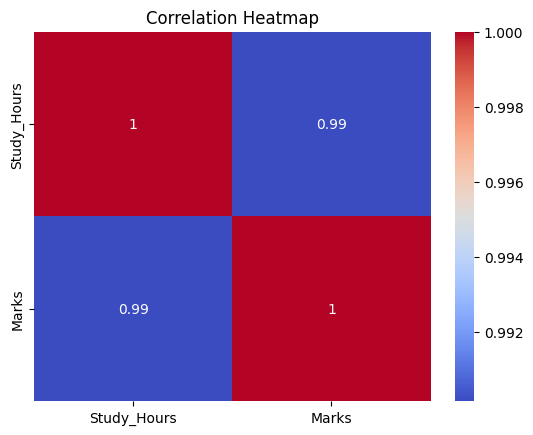

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Given data
data = {
    'Study_Hours': [2, 4, 6, 8, 10],
    'Marks': [50, 60, 65, 80, 90]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate correlation matrix
corr_matrix = df.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Q2: Sampling Methods from a Population

## Objective

To select samples from a population using different sampling techniques:

* Random Sampling
* Systematic Sampling
* Stratified Sampling

## Population

A population of numbers from 1 to 100 is used.

## Methods

### 1. Random Sampling

Selects samples randomly where each element has an equal chance of selection.

### 2. Systematic Sampling

Selects every k-th element from the population.

### 3. Stratified Sampling

Divides the population into groups (strata) and takes samples from each group.

## Tools Used

* Python
* NumPy
* Pandas

## Output

Displays selected samples for each sampling method.

## Use Case

Used in statistics, surveys, and data analysis to reduce bias and improve representation.

In [7]:
import numpy as np
import pandas as pd

# Population (example: 1 to 100)
population = np.arange(1, 101)

print("Population Size:", len(population))

# -------------------------
# 1️⃣ Random Sampling
# -------------------------
random_sample = np.random.choice(population, size=10, replace=False)
print("\nRandom Sample:", random_sample)


# -------------------------
# 2️⃣ Systematic Sampling
# -------------------------
k = len(population) // 10   # interval
systematic_sample = population[::k][:10]
print("\nSystematic Sample:", systematic_sample)


# -------------------------
# 3️⃣ Stratified Sampling
# Divide population into 2 strata: 1-50 and 51-100
# -------------------------
strata1 = population[:50]
strata2 = population[50:]

sample1 = np.random.choice(strata1, size=5, replace=False)
sample2 = np.random.choice(strata2, size=5, replace=False)

stratified_sample = np.concatenate([sample1, sample2])
print("\nStratified Sample:", stratified_sample)

Population Size: 100

Random Sample: [ 5  7 28 98 62 52 99 21 46 29]

Systematic Sample: [ 1 11 21 31 41 51 61 71 81 91]

Stratified Sample: [ 39  49  25  41  10  85  70 100  86  75]


# Q3: Z-Test for Hypothesis Testing

## Objective

To perform a Z-test to determine whether the sample mean significantly differs from the population mean.

## Hypothesis

* H0 (Null Hypothesis): Sample mean = Population mean
* H1 (Alternative Hypothesis): Sample mean ≠ Population mean

## Steps

1. Calculate sample mean
2. Use known population standard deviation
3. Compute Z value
4. Calculate p-value
5. Compare with significance level (α = 0.05)
6. Make decision:

   * Reject H0 if p-value < 0.05
   * Otherwise, fail to reject H0

## Tools Used

* Python
* NumPy
* SciPy

## Output

Displays:

* Sample mean
* Z value
* P-value
* Decision (Reject / Fail to Reject H0)

## Use Case

Widely used in statistical testing, quality control, and research analysis.

In [8]:
import numpy as np
from scipy.stats import norm

# Sample data
data = [52, 55, 50, 48, 54, 53, 51, 49, 52, 50]

# Given values
population_mean = 50
population_std = 5   # known
n = len(data)

# Sample mean
sample_mean = np.mean(data)

# Z formula
z = (sample_mean - population_mean) / (population_std / np.sqrt(n))

# p-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z)))

print("Sample Mean:", sample_mean)
print("Z value:", z)
print("P value:", p_value)

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Sample Mean: 51.4
Z value: 0.8854377448471454
P value: 0.37592058254807514
Fail to Reject Null Hypothesis
